# Worked example: reaching the businesses your outreach actually helps

**Scenario (synthetic).** A community lender has a list of 4,000 small businesses: technical-assistance
alumni, past inquiries, past borrowers, and referral-partner lists. Its loan officers can make about
**1,000 outreach contacts** (a call plus a mailed information pack, about **$30 each**) per campaign. Who should
they contact?

To find out, it ran a **randomized pilot** on the whole list. Half the list was contacted at random and half was
left as a holdout. It then recorded who applied, and who was funded, within 60 days.

All data here is simulated by `synthetic_data.py`. Because it is simulated, we also know each prospect's **true**
effect of outreach, which lets us check which targeting method really worked. In a real campaign you
never know this.

| Section | Guide chapter |
|---|---|
| 1. How big a test? | 02 |
| 2. Did outreach work at all? | 03 |
| 3. Which segments does it work for? | 04 |
| 4. Uplift models vs a response model | 05 |
| 5. How much data before a model beats a segment table? | 05 |
| 6. Choosing who to contact next, and who that reaches | 06, 07 |
| 7. Keep a holdout | 08 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from synthetic_data import generate, generate_next_list, FEATURES
from uplift_tools import (
    sample_size_per_group, minimum_detectable_lift, lift_with_ci, cost_per_incremental,
    segment_lift, fit_t_learner, fit_transformed_outcome, fit_response_model,
    qini_curve, qini_coefficient, policy_value, select_with_floor, reach_report,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Chart colors: categorical slots 1-4 of a CVD-validated palette; gray dashed = random reference.
COLORS = {"Segment rule": "#2a78d6", "T-learner": "#eb6834", "Transformed outcome": "#1baf7a",
          "Response model": "#eda100", "Random": "#8a8983"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "lines.linewidth": 2,
                     "font.size": 10, "axes.edgecolor": "#b4b2a9", "figure.dpi": 110})

COST_PER_CONTACT = 30
pilot = generate(n=4000, seed=11)
pilot[["applied", "funded", "contacted"]].mean()

applied     0.0892
funded      0.0550
contacted   0.5075
dtype: float64

## 1. How big a test do you need?

Before running a pilot, check that it can detect the effect you care about. Suppose about 4% of prospects apply
without outreach, and you want to detect outreach adding 2 percentage points (to 6%).

In [2]:
print("50/50 split:", sample_size_per_group(p_control=0.04, lift=0.02, holdout_share=0.5))
print("80/20 split:", sample_size_per_group(p_control=0.04, lift=0.02, holdout_share=0.2))
print(f"Smallest lift a 4,000-prospect 50/50 test can detect: {minimum_detectable_lift(4000, 0.04):.1%} points")

50/50 split: {'holdout': 1861, 'contacted': 1861, 'total': 3722}
80/20 split: {'holdout': 1031, 'contacted': 4124, 'total': 5155}
Smallest lift a 4,000-prospect 50/50 test can detect: 1.9% points


**Reading it:** detecting a 2-point lift from a 4% base needs about 3,700 prospects split 50/50. A smaller holdout
(20%) leaves fewer people uncontacted but needs a larger list, about 5,200. A 4,000-prospect pilot can detect a
lift of about 1.9 points. **If your list is much smaller than this, pool two campaigns or test a bigger
change.** A test too small to detect the effect only produces noise.

## 2. Did outreach work at all?

The first question is not *who* to target, but *whether outreach changes anything*. Compare application and
funding rates between contacted and holdout.

In [3]:
rows = {o: lift_with_ci(pilot, "contacted", o) for o in ["applied", "funded"]}
pd.DataFrame(rows).T[["n_contacted", "n_holdout", "rate_contacted", "rate_holdout", "lift", "ci_low", "ci_high", "p_value"]]

,n_contacted,n_holdout,rate_contacted,rate_holdout,lift,ci_low,ci_high,p_value
applied,"2,030.0000","1,970.0000",0.0995,0.0787,0.0208,0.0032,0.0385,0.0206
funded,"2,030.0000","1,970.0000",0.0635,0.0462,0.0174,0.0033,0.0314,0.0158


In [4]:
f = rows["funded"]
cpi = cost_per_incremental(f["lift"], f["ci_low"], f["ci_high"], COST_PER_CONTACT)
naive = COST_PER_CONTACT / f["rate_contacted"]
share_anyway = f["rate_holdout"] / f["rate_contacted"]
print(f"Naive cost per funded loan among those contacted:   ${naive:,.0f}")
print(f"Cost per INCREMENTAL funded loan (point estimate):   ${cpi['point']:,.0f}  "
      f"(range ${cpi['best_case']:,.0f} to ${cpi['worst_case']:,.0f})")
print(f"Share of contacted-and-funded loans that would have happened anyway: {share_anyway:.0%}")

Naive cost per funded loan among those contacted:   $472
Cost per INCREMENTAL funded loan (point estimate):   $1,729  (range $954 to $9,191)
Share of contacted-and-funded loans that would have happened anyway: 73%


**Reading it:** outreach raised the funded-loan rate by about 1.7 points (interval roughly 0.3 to 3.1), a
statistically significant effect. But the naive view, "we contacted 2,030 businesses and 129 were funded", credits
outreach with loans that **mostly would have happened anyway**: about 73% of them, based on the holdout's rate. The
honest cost is about **$1,700 per incremental funded loan**, not $470. That is the number to compare with other
uses of loan-officer time.

## 3. Which segments does outreach work for?

Define a handful of segments **before** looking at results, based on what staff already know about prospects.
Here there are four: recently declined applicants; already-engaged businesses (a recent inquiry or a past borrower);
technical-assistance (TA) alumni without a loan; and everyone else.

In [5]:
def assign_segment(d):
    return np.select(
        [d["recently_declined"] == 1, (d["recent_inquiry"] == 1) | (d["prior_borrower"] == 1), d["prior_ta"] == 1],
        ["recently declined", "already engaged", "TA alumni, no loan"], "other")

pilot["segment"] = assign_segment(pilot)
seg = segment_lift(pilot, "segment", "contacted", "applied").sort_values("lift_shrunk", ascending=False)
seg

,segment,prospects,rate_holdout,rate_contacted,lift,ci_low,ci_high,lift_shrunk
0,"TA alumni, no loan",957,0.0309,0.1168,0.0859,0.0531,0.1187,0.0786
1,already engaged,1144,0.1753,0.1866,0.0113,-0.0333,0.0559,0.0131
2,other,1648,0.0368,0.0407,0.0040,-0.0146,0.0226,0.0047
3,recently declined,251,0.0840,0.0455,-0.0386,-0.0998,0.0226,-0.0204


**Reading it:**

* **Already engaged** businesses apply at about 18% *whether or not they are contacted*. Outreach adds about 1 point,
  and the interval includes zero. These are the "sure things". A response model ranks them first, because they
  respond. But contacting them mostly spends staff time on applications that were coming anyway.
* **TA alumni without a loan** apply at 3% without outreach and about 12% with it, a lift of about 9 points. These are
  the "persuadables", and they are where outreach earns its cost.
* **Recently declined** applicants apply *less* when contacted (the interval is wide, but the direction is a warning).
  Being contacted soon after a decline can read as pressure, or as a signal nothing has changed.
* `lift_shrunk` pulls each estimate toward the overall lift according to its uncertainty, so a small segment with a
  lucky result is not ranked first on luck alone.

## 4. Uplift models vs a response model

With enough data, a model can rank *individual* prospects by their expected lift. We compare, on a 40% hold-out of the
randomized pilot:

* **Response model:** the conventional approach. Predicts who applies when contacted.
* **T-learner:** two models (contacted and not contacted). Uplift = difference in predicted application rate.
* **Transformed outcome:** a single model on a transformed target (Jaskowski & Jaroszewicz, 2012).
* **Segment rule:** the shrunk segment lifts from section 3, re-estimated on the training part only.

The **Qini curve** shows how many incremental applications you get as you contact more of the list, in score order.
A good targeting score rises steeply first. Random targeting is a straight line.

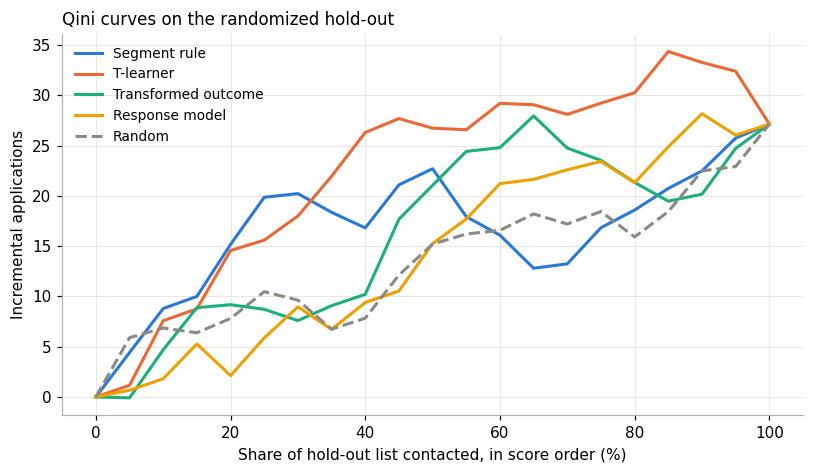

,method,qini_coefficient,est_incremental_per_1000 (top 25%),ci_low,ci_high,TRUE incremental_per_1000 (simulation only)
0,Segment rule,0.1180,103.9860,51.1870,165.4730,64.0870
1,T-learner,0.3370,77.2080,13.9250,140.4680,44.9860
2,Transformed outcome,0.0930,43.1540,-5.9280,97.8830,31.2430
3,Response model,0.0290,28.9320,-42.6620,110.9840,29.3050
4,Random,-0.0050,49.1580,-2.4320,95.2570,21.2740


In [6]:
train, test = train_test_split(pilot, test_size=0.4, random_state=0, stratify=pilot["contacted"])
seg_train = segment_lift(train, "segment", "contacted", "applied").set_index("segment")["lift_shrunk"]
tiebreak = np.random.default_rng(0).random(len(test)) * 1e-6

scores = {
    "Segment rule": test["segment"].map(seg_train).values + tiebreak,
    "T-learner": fit_t_learner(train, FEATURES, "contacted", "applied")(test),
    "Transformed outcome": fit_transformed_outcome(train, FEATURES, "contacted", "applied")(test),
    "Response model": fit_response_model(train, FEATURES, "contacted", "applied")(test),
    "Random": np.random.default_rng(1).random(len(test)),
}

fig, ax = plt.subplots(figsize=(7.5, 4.4))
summary = []
for name, s in scores.items():
    curve = qini_curve(test["applied"], test["contacted"], s)
    style = "--" if name == "Random" else "-"
    ax.plot(curve["share_targeted"] * 100, curve["incremental"], style, color=COLORS[name], label=name)
    pv = policy_value(test, s, 0.25, "contacted", "applied")
    top = np.argsort(-s)[: int(len(test) * 0.25)]
    summary.append({"method": name, "qini_coefficient": qini_coefficient(curve),
                    "est_incremental_per_1000 (top 25%)": pv["incremental_per_1000_contacts"],
                    "ci_low": pv["ci_low"], "ci_high": pv["ci_high"],
                    "TRUE incremental_per_1000 (simulation only)": 1000 * test["true_effect"].values[top].mean()})
ax.set_xlabel("Share of hold-out list contacted, in score order (%)")
ax.set_ylabel("Incremental applications")
ax.set_title("Qini curves on the randomized hold-out", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
pd.DataFrame(summary).round(3)

**Reading it:**

* The **response model** hardly beats random. It ranks the already-engaged first: they apply often, but they would
  have applied anyway.
* The **segment rule** and the **T-learner** both do far better, and on the *true* effect (known only because the
  data is simulated) the segment rule is best at this sample size.
* The estimated values for the top 25% have **wide intervals**. With about 200 prospects per arm in the top slice,
  a single hold-out cannot rank close methods reliably. Here the Qini coefficient even ranks the T-learner above the segment rule, the opposite of the true result. Treat model comparisons at this scale as rough, and prefer
  the simpler method unless a model wins clearly.

## 5. How much data before a model beats a segment table?

A simulation question that a real lender cannot answer from one pilot. For pilots of different sizes, train each
method, target the top 25% of a fresh 20,000-prospect list, and measure what share of the **best possible**
incremental applications each method captures (averaged over 3 runs).

In [7]:
fresh = generate_next_list(20000, seed=99)
fresh["segment"] = assign_segment(fresh)
k = 5000
best = np.sort(fresh["true_effect"].values)[::-1][:k].sum()

results = []
for n in [2000, 4000, 10000, 40000]:
    for run in range(3):
        d = generate(n, seed=100 + run)
        d["segment"] = assign_segment(d)
        seg_d = segment_lift(d, "segment", "contacted", "applied").set_index("segment")["lift_shrunk"]
        sc = {
            "Segment rule": fresh["segment"].map(seg_d).values + np.random.default_rng(run).random(len(fresh)) * 1e-6,
            "T-learner": fit_t_learner(d, FEATURES, "contacted", "applied", seed=run)(fresh),
            "Transformed outcome": fit_transformed_outcome(d, FEATURES, "contacted", "applied", seed=run)(fresh),
            "Response model": fit_response_model(d, FEATURES, "contacted", "applied", seed=run)(fresh),
        }
        for name, s in sc.items():
            results.append({"pilot_size": n, "method": name,
                            "share_of_best": fresh["true_effect"].values[np.argsort(-s)[:k]].sum() / best})
res = results_df = pd.DataFrame(results).groupby(["pilot_size", "method"])["share_of_best"].mean().unstack()
res["Random"] = fresh["true_effect"].mean() * k / best
res.round(2)

method,Response model,Segment rule,T-learner,Transformed outcome,Random
pilot_size,,,,,
2000,0.4200,0.8500,0.5500,0.3100,0.3000
4000,0.3900,0.6700,0.6000,0.4300,0.3000
10000,0.3600,0.8600,0.7300,0.4700,0.3000
40000,0.3900,0.8600,0.9100,0.7300,0.3000


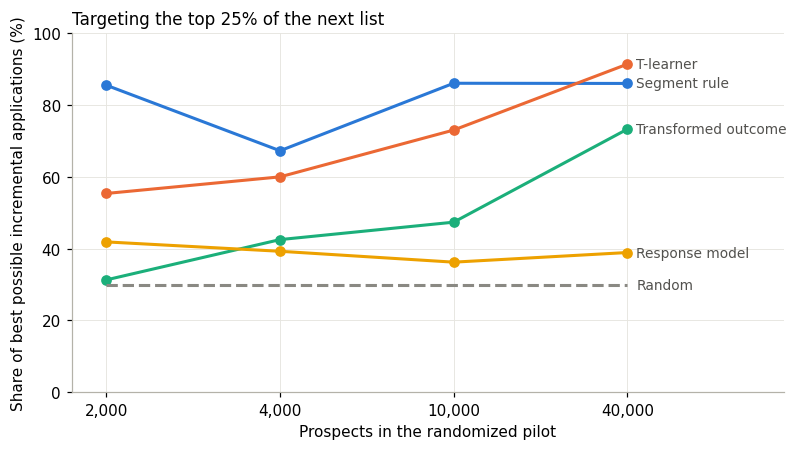

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(res.index))
for name in ["Segment rule", "T-learner", "Transformed outcome", "Response model", "Random"]:
    style = "--" if name == "Random" else "-o"
    ax.plot(x, res[name] * 100, style, color=COLORS[name], label=name, markersize=6)
    ax.annotate(name, (x[-1], res[name].iloc[-1] * 100), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color="#52514e")
ax.set_xticks(x, [f"{n:,}" for n in res.index])
ax.set_xlim(-0.2, len(x) - 1 + 0.9)
ax.set_ylim(0, 100)
ax.set_xlabel("Prospects in the randomized pilot")
ax.set_ylabel("Share of best possible incremental applications (%)")
ax.set_title("Targeting the top 25% of the next list", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

**Reading it:**

* A **response model** captures about 40% of what is possible, at every pilot size. More data does not fix it,
  because it answers the wrong question.
* A **segment table** from a randomized pilot captures most of what is possible from the smallest pilot upward, *provided the
  segments reflect real knowledge of the prospects*. Poorly chosen segments would do worse.
* The **T-learner** needs roughly 40,000 randomized prospects to match or beat a well-chosen segment table.
  The transformed-outcome model needs more still.

For most community lenders, whose lists run to hundreds or a few thousand, **the practical recipe is: randomize, measure,
segment, and hold the model back** until pooled campaigns reach tens of thousands of prospects.

## 6. Choosing who to contact next, and who that reaches

The next campaign's list has 4,000 new prospects and capacity for 1,000 contacts. Each method is trained on the full pilot.
Because the data is simulated, we can report the **true** incremental applications each choice produces.

The reach check matters for mission and for certification. A certified CDFI must direct at least 60% of its financing
activity, by number and by dollar volume, to its target markets. Here `lmi_tract` stands in for the target market.
Outreach that drifts toward already-connected, higher-income businesses erodes that share over time.

In [9]:
nxt = generate_next_list(4000, seed=12)
nxt["segment"] = assign_segment(nxt)
seg_all = segment_lift(pilot, "segment", "contacted", "applied").set_index("segment")["lift_shrunk"]
policy_scores = {
    "Segment rule": nxt["segment"].map(seg_all).values + np.random.default_rng(2).random(len(nxt)) * 1e-6,
    "T-learner": fit_t_learner(pilot, FEATURES, "contacted", "applied")(nxt),
    "Response model": fit_response_model(pilot, FEATURES, "contacted", "applied")(nxt),
    "Random": np.random.default_rng(3).random(len(nxt)),
}
rows = []
for name, s in policy_scores.items():
    chosen = np.zeros(len(nxt), dtype=bool); chosen[np.argsort(-s)[:1000]] = True
    r = reach_report(nxt, chosen, ["lmi_tract", "prior_borrower"])
    inc = nxt.loc[chosen, "true_effect"].sum()
    rows.append({"method": name, "true_incremental_applications": inc,
                 "outreach_cost_per_incremental_application": 1000 * COST_PER_CONTACT / inc,
                 "LMI share of contacts": r["lmi_tract_share_of_contacts"],
                 "past-borrower share of contacts": r["prior_borrower_share_of_contacts"]})
policies = pd.DataFrame(rows).set_index("method")
print(f"LMI share of the whole list: {nxt['lmi_tract'].mean():.0%}")
policies.round(2)

LMI share of the whole list: 58%


,true_incremental_applications,outreach_cost_per_incremental_application,LMI share of contacts,past-borrower share of contacts
method,,,,
Segment rule,64.4500,465.4700,0.6600,0.0100
T-learner,47.1000,636.9300,0.5900,0.2000
Response model,31.5400,951.2400,0.6000,0.3300
Random,21.6700,"1,384.5000",0.6000,0.1900


**Reading it:** for the same 1,000 contacts and $30,000, the segment rule produces about three times as many
extra applications as random outreach, and about twice as many as the response model. The response model's contacts are
disproportionately past borrowers, businesses that already have a relationship with the lender. In this simulation,
targeting on incremental effect *also* reaches a higher share of LMI-tract businesses, because the persuadable
TA alumni are concentrated there.

That alignment is a feature of this simulated list, not a guarantee. The next cell shows the guard to use when a
targeting rule would push reach below a floor.

In [10]:
floor_rows = []
for name in ["T-learner", "Response model"]:
    s = policy_scores[name]
    for floor in [None, 0.65]:
        if floor is None:
            chosen = np.zeros(len(nxt), dtype=bool); chosen[np.argsort(-s)[:1000]] = True
        else:
            chosen = select_with_floor(nxt, s, 1000, "lmi_tract", floor)
        floor_rows.append({"method": name, "LMI floor": floor or "none",
                           "LMI share of contacts": nxt.loc[chosen, "lmi_tract"].mean(),
                           "true_incremental_applications": nxt.loc[chosen, "true_effect"].sum()})
pd.DataFrame(floor_rows).round(3)

,method,LMI floor,LMI share of contacts,true_incremental_applications
0,T-learner,none,0.5900,47.1010
1,T-learner,0.6500,0.6500,48.4660
2,Response model,none,0.5960,31.5380
3,Response model,0.6500,0.6500,32.3870


**Reading it:** `select_with_floor` fills the required share of contacts from the highest-scoring target-market
prospects first, then fills the rest by score. Here a 65% floor costs little or nothing in incremental applications. When it
does cost something, that cost is the explicit price of the mission constraint, and it belongs in the campaign record.

## 7. Keep a holdout in every campaign

Targeting rules go stale: the list changes, the product changes, the economy changes. Keep a small random holdout
(10–20%) from the *targeted* group in every campaign. It costs little and keeps measuring whether outreach still works.
It is the uplift equivalent of the model-monitoring checks in the companion
[Lending Model Monitoring Guide](https://github.com/hannahxuhang-hue/lending-model-monitoring-guide).

In [11]:
for n_targeted in [1000, 2000, 4000]:
    mdl = minimum_detectable_lift(n_targeted, p_control=0.05, holdout_share=0.15)
    print(f"{n_targeted:>5,} targeted prospects, 15% holdout: detectable lift ≈ {mdl:.1%} points")

1,000 targeted prospects, 15% holdout: detectable lift ≈ 5.8% points
2,000 targeted prospects, 15% holdout: detectable lift ≈ 4.0% points
4,000 targeted prospects, 15% holdout: detectable lift ≈ 2.8% points


**Reading it:** a single 1,000-contact campaign with a 15% holdout can only detect a large lift (about 6 points).
Pool holdouts across campaigns: after four campaigns the pooled test can detect about 3 points, enough to notice if
outreach to the targeted segment has stopped working.